Data berhasil dibuat! Ini 5 data pertama:
   usia_asli  skor_stres  olahraga_mingguan  makan_sehat  usia_jantung
0         58           8                  6            1          63.5
1         48           9                  0            2          60.5
2         34           5                  0            3          40.0
3         62           6                  5            5          63.5
4         27           4                  6            5          24.5
AI sudah selesai belajar!
Hasil Analisis AI:
Usia Asli Pasien: 30 tahun
Prediksi Usia Jantung: 44.0 tahun


c:\Users\LENOVO ThinkPad T480\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


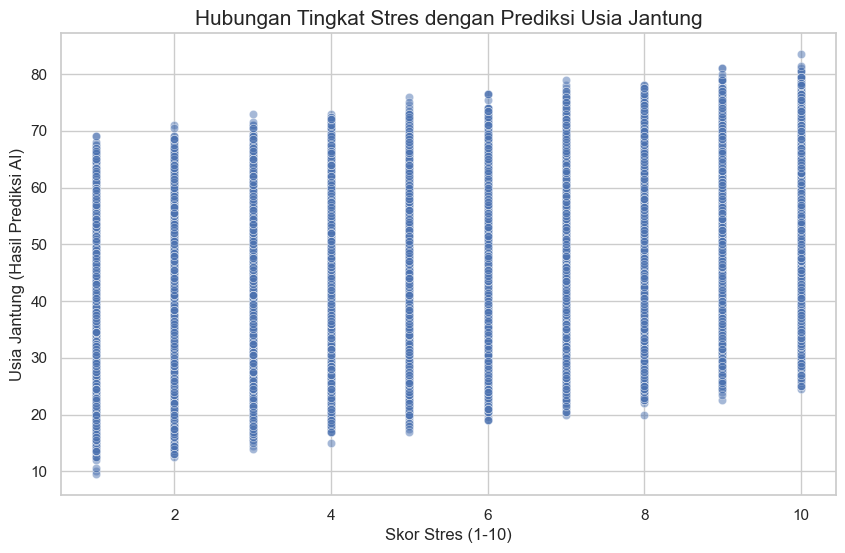

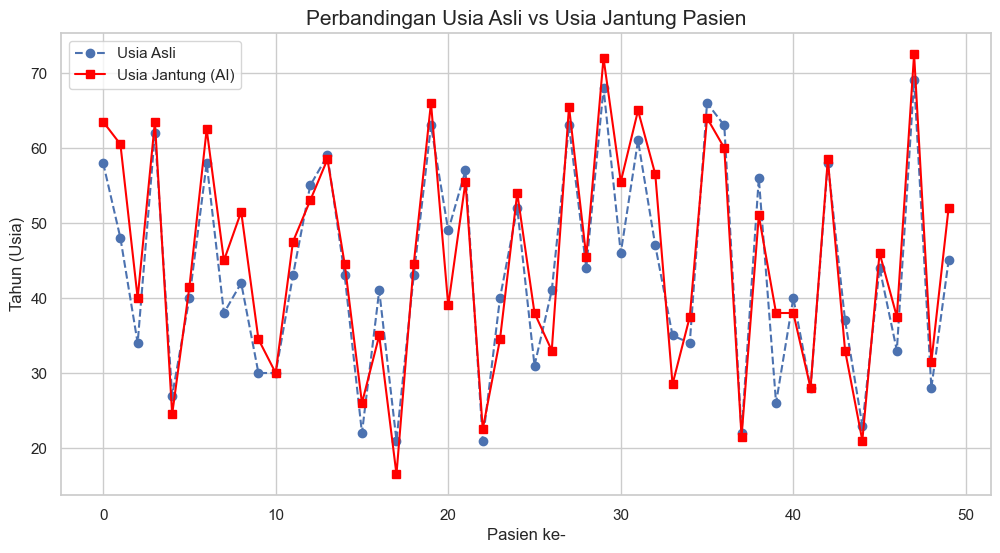

In [6]:
import pandas as pd
import numpy as np

# 1. Membuat 10000 data acak
np.random.seed(42) # Agar hasil acaknya selalu sama setiap kali dijalankan
n_pasien = 10000

data = {
    'usia_asli': np.random.randint(20, 70, n_pasien),      # Usia antara 20 - 70 tahun
    'skor_stres': np.random.randint(1, 11, n_pasien),     # Skala stres 1 - 10
    'olahraga_mingguan': np.random.randint(0, 8, n_pasien),# Berapa kali olahraga seminggu
    'makan_sehat': np.random.randint(1, 11, n_pasien)     # Skala makan sehat 1 - 10
}

df = pd.DataFrame(data)


# 2. Membuat "Rumus Rahasia" untuk Usia Jantung (Label)
# Kita buat logika: Stres nambah umur (+1.5), Olahraga ngurangin (-1), Makan sehat ngurangin (-0.5)
df['usia_jantung'] = df['usia_asli'] + (df['skor_stres'] * 1.5) - (df['olahraga_mingguan'] * 1) - (df['makan_sehat'] * 0.5)

print("Data berhasil dibuat! Ini 5 data pertama:")
print(df.head())

#Logika dan machine learning yang digunakan
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Memisahkan Fitur (X) dan Target (y)
X = df[['usia_asli', 'skor_stres', 'olahraga_mingguan', 'makan_sehat']] # Input
y = df['usia_jantung'] # Jawaban yang ingin ditebak

# 2. Bagi data: 80% untuk belajar, 20% untuk ujian (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Panggil Mesin AI (Linear Regression)
model_ai = LinearRegression()

# 4. PROSES BELAJAR (Training)
model_ai.fit(X_train, y_train)

print("AI sudah selesai belajar!")

# Mari kita buat data pasien baru: Usia 20, Stres 10 (Maksimal), Olahraga 0, Makan Sehat 2
pasien_baru = [[30, 10, 0, 2]] 
prediksi = model_ai.predict(pasien_baru)

print(f"Hasil Analisis AI:")
print(f"Usia Asli Pasien: 30 tahun")
print(f"Prediksi Usia Jantung: {prediksi[0]:.1f} tahun")

#untuk menampilkan grafik 
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tampilan grafik agar lebih cantik
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))


# Membuat Scatter Plot (Titik-titik data)
sns.scatterplot(x='skor_stres', y='usia_jantung', data=df, alpha=0.5)

# Menambahkan judul dan label
plt.title('Hubungan Tingkat Stres dengan Prediksi Usia Jantung', fontsize=15)
plt.xlabel('Skor Stres (1-10)', fontsize=12)
plt.ylabel('Usia Jantung (Hasil Prediksi AI)', fontsize=12)

plt.show()

plt.figure(figsize=(12, 6))

# Mengambil 50 data pertama saja agar grafik tidak terlalu penuh
df_sample = df.head(50)

# Membuat grafik garis
plt.plot(df_sample['usia_asli'], label='Usia Asli', marker='o', linestyle='--')
plt.plot(df_sample['usia_jantung'], label='Usia Jantung (AI)', marker='s', color='red')

plt.title('Perbandingan Usia Asli vs Usia Jantung Pasien', fontsize=15)
plt.ylabel('Tahun (Usia)', fontsize=12)
plt.xlabel('Pasien ke-', fontsize=12)
plt.legend() # Menampilkan keterangan garis

plt.show()
